In [1]:
#1a
import torch
import torch.nn as nn
import torchvision.models as models

# Load the pre-trained ResNet-152 model
# The 'weights' parameter ensures we download the model pre-trained on ImageNet
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 153MB/s]


In [2]:
#1c
# Iterate through all parameters in the model and disable gradient computation
for param in model.parameters():
    param.requires_grad = False

In [3]:
#1b
# Get the number of input features to the final fully connected layer
num_ftrs = model.fc.in_features

# Replace the final layer with a new one designed for 10 classes (CIFAR-10)
model.fc = nn.Linear(num_ftrs, 10)

# Verify that only the final layer will be trained
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Trainable layer: {name}")

Trainable layer: fc.weight
Trainable layer: fc.bias


In [4]:
#For Future Data usage
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim

# Define the transformations expected by the pre-trained ResNet
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
data_path = '/content/drive/MyDrive/ColabProjects/CIFAR10/data'

# Load the CIFAR-10 training and validation datasets
trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

valset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=True, transform=transform)
valloader = DataLoader(valset, batch_size=64, shuffle=False, num_workers=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Move the model to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print (device)


100%|██████████| 170M/170M [22:41<00:00, 125kB/s]


cuda


In [8]:
num_epochs = 3
history = {'train_loss': [], 'val_accuracy': []}

for epoch in range(num_epochs):

    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()           # 1. Zero the gradients
        outputs = model(inputs)         # 2. Forward pass
        loss = criterion(outputs, labels) # 3. Compute loss
        loss.backward()                 # 4. Backward pass
        optimizer.step()                # 5. Update weights

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    history['train_loss'].append(epoch_loss)

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout/batchnorm updates)
    correct = 0
    total = 0

    # Disable gradient tracking for validation to save memory and compute
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1) # Get the index of the max log-probability

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

Epoch 1/3 | Train Loss: 0.6967 | Val Accuracy: 82.78%
Epoch 2/3 | Train Loss: 0.4924 | Val Accuracy: 84.42%
Epoch 3/3 | Train Loss: 0.4502 | Val Accuracy: 84.02%


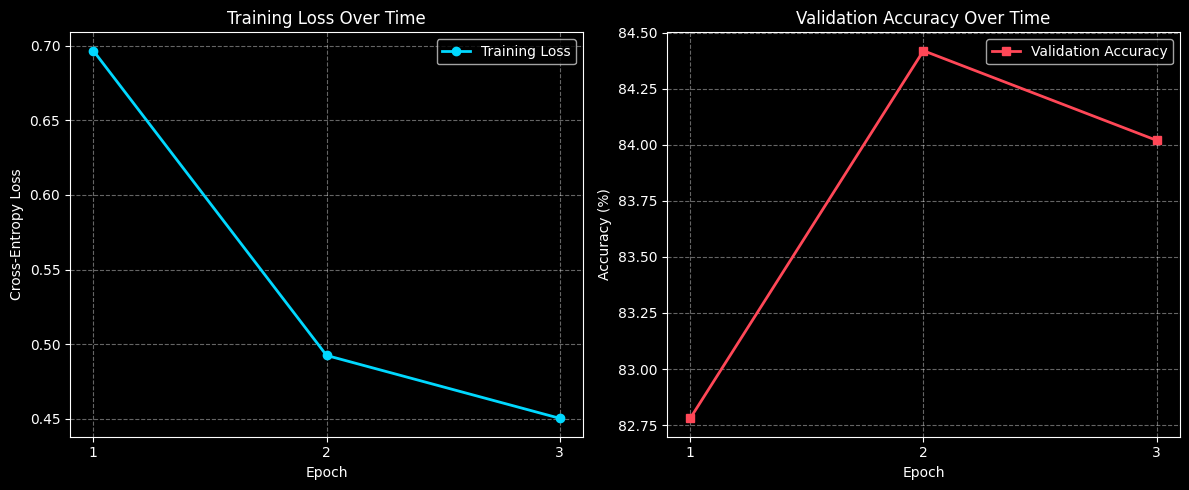

In [9]:
import matplotlib.pyplot as plt

# Apply a dark background style for the plots
plt.style.use('dark_background')

# Extract epoch numbers for the x-axis
epochs = range(1, len(history['train_loss']) + 1)

# Set up a wider figure to hold side-by-side subplots
plt.figure(figsize=(12, 5))

# --- Subplot 1: Training Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], marker='o', color='#00d8ff', linestyle='-', linewidth=2, label='Training Loss')
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

# --- Subplot 2: Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history['val_accuracy'], marker='s', color='#ff4757', linestyle='-', linewidth=2, label='Validation Accuracy')
plt.title('Validation Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

# Automatically adjust padding so axis labels do not overlap
plt.tight_layout()
plt.show()

In [ ]:
# #For Future Data usage
# from google.colab import drive
# drive.mount('/content/drive')

# # Create a folder in your Drive for the dataset
# !mkdir -p /content/drive/MyDrive/ColabProjects/CIFAR10

# # Copy the contents of the temporary data folder to your Drive
# !cp -r ./data /content/drive/MyDrive/ColabProjects/CIFAR10/

In [ ]:
# data_path = '/content/drive/MyDrive/ColabProjects/CIFAR10/data'

# trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=True, transform=transform)

Skip connections successfully disabled in model_no_skip.layer4

Starting training for model WITHOUT skip connections...
Epoch 1/3 | Train Loss: 2.1914 | Val Accuracy: 26.61%
Epoch 2/3 | Train Loss: 2.0727 | Val Accuracy: 31.68%
Epoch 3/3 | Train Loss: 2.0118 | Val Accuracy: 33.44%


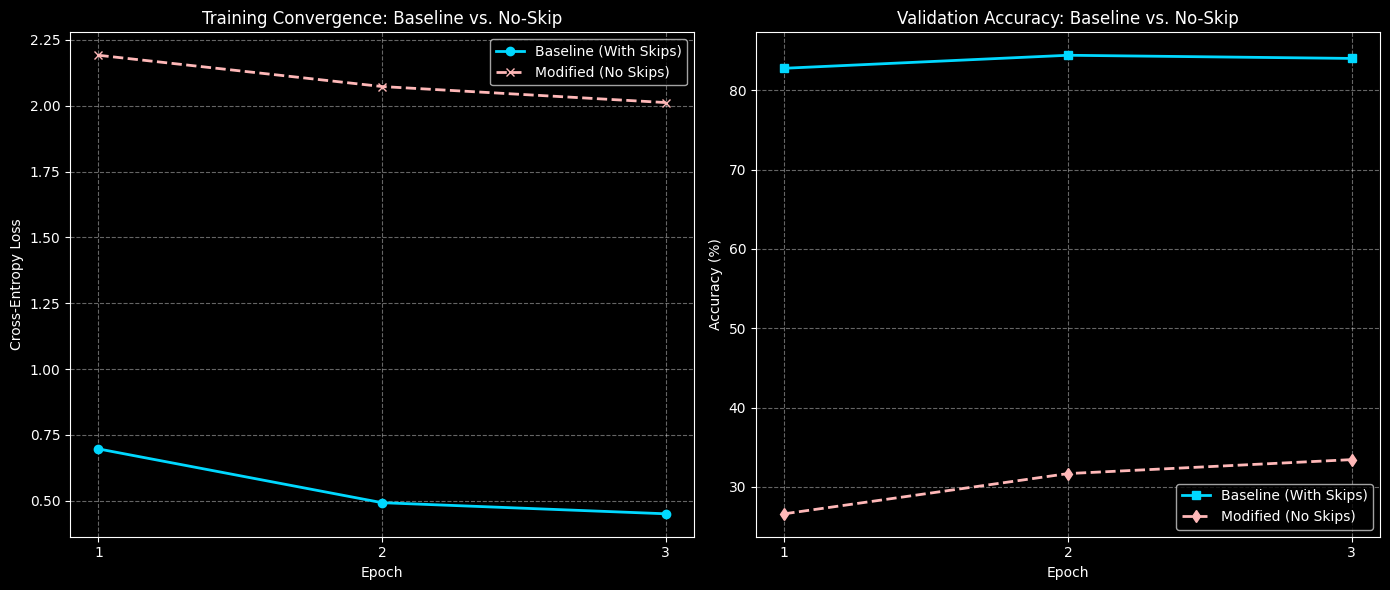

In [10]:
import types
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP MODIFIED MODEL (Disable Skips)
# ==========================================
# Load a fresh pre-trained model
model_no_skip = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

# Freeze the backbone
for param in model_no_skip.parameters():
    param.requires_grad = False

# Replace classification head for CIFAR-10
num_ftrs = model_no_skip.fc.in_features
model_no_skip.fc = nn.Linear(num_ftrs, 10)

# Define the custom forward pass without the residual addition
def forward_no_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    # The skip connection (out += identity) is intentionally omitted here
    out = self.relu(out)
    return out

# Patch the modified forward pass into all blocks of layer 4
for block in model_no_skip.layer4:
    block.forward = types.MethodType(forward_no_skip, block)

print("Skip connections successfully disabled in model_no_skip.layer4")

# ==========================================
# 2. TRAINING LOOP FOR MODIFIED MODEL
# ==========================================
model_no_skip = model_no_skip.to(device)
optimizer_no_skip = optim.Adam(model_no_skip.fc.parameters(), lr=0.001)

num_epochs = 3
history_no_skip = {'train_loss': [], 'val_accuracy': []}

print("\nStarting training for model WITHOUT skip connections...")
for epoch in range(num_epochs):

    # --- TRAINING PHASE ---
    model_no_skip.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_no_skip.zero_grad()
        outputs = model_no_skip(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_no_skip.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    history_no_skip['train_loss'].append(epoch_loss)

    # --- VALIDATION PHASE ---
    model_no_skip.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_no_skip(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    history_no_skip['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

# ==========================================
# 3. PLOT COMPARISON (Part 1 vs Part 2)
# ==========================================
# This plots the 'history' from Part 1 against 'history_no_skip' from Part 2

plt.style.use('dark_background')
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 6))

# --- Subplot 1: Training Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], marker='o', color='#00d8ff', linestyle='-', linewidth=2, label='Baseline (With Skips)')
plt.plot(epochs, history_no_skip['train_loss'], marker='x', color='#ffb8b8', linestyle='--', linewidth=2, label='Modified (No Skips)')
plt.title('Training Convergence: Baseline vs. No-Skip')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

# --- Subplot 2: Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history['val_accuracy'], marker='s', color='#00d8ff', linestyle='-', linewidth=2, label='Baseline (With Skips)')
plt.plot(epochs, history_no_skip['val_accuracy'], marker='d', color='#ffb8b8', linestyle='--', linewidth=2, label='Modified (No Skips)')
plt.title('Validation Accuracy: Baseline vs. No-Skip')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

Extracting features for Part 3...
Running t-SNE for early layer...
Running t-SNE for middle layer...
Running t-SNE for late layer...


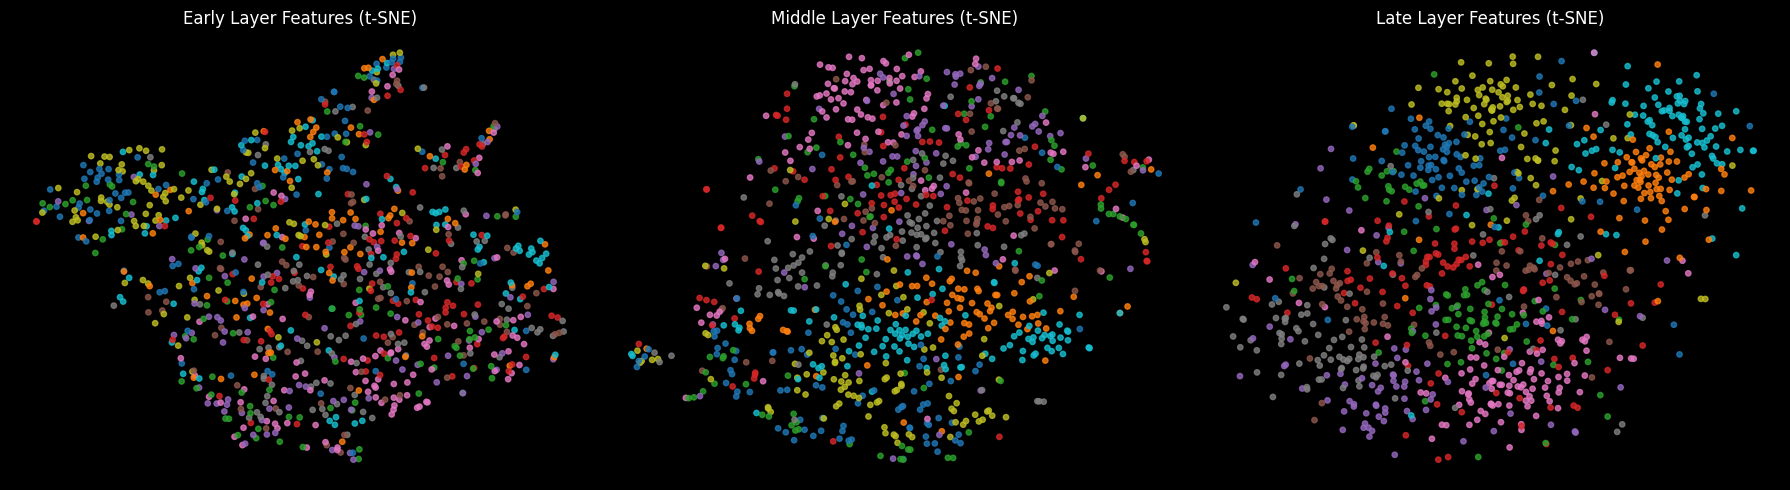

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ==========================================
# PART 3: EXTRACT AND VISUALIZE FEATURES
# ==========================================
print("Extracting features for Part 3...")

# 1. Dictionary to store the extracted features
features = {'early': [], 'middle': [], 'late': []}
labels_list = []

# 2. Define a hook function to capture the output of a layer
def get_features(layer_name):
    def hook(model, input, output):
        # Apply Global Average Pooling to flatten the spatial dimensions (H, W)
        pooled_output = output.mean(dim=[2, 3]).detach().cpu().numpy()
        features[layer_name].append(pooled_output)
    return hook

# 3. Register hooks to specific layers in your trained Part 1 'model'
# layer1 (Early), layer3 (Middle), layer4 (Late)
handle_early = model.layer1.register_forward_hook(get_features('early'))
handle_mid = model.layer3.register_forward_hook(get_features('middle'))
handle_late = model.layer4.register_forward_hook(get_features('late'))

# 4. Run a subset of validation data through the model to collect features
model.eval()
num_samples_to_collect = 1000 # Limit to 1000 to keep t-SNE computation fast
samples_collected = 0

with torch.no_grad():
    for inputs, labels in valloader:
        inputs = inputs.to(device)
        _ = model(inputs) # The hooks will intercept the features during this pass

        labels_list.append(labels.cpu().numpy())
        samples_collected += inputs.size(0)

        if samples_collected >= num_samples_to_collect:
            break

# 5. Clean up the hooks so they don't interfere with future training
handle_early.remove()
handle_mid.remove()
handle_late.remove()

# 6. Concatenate lists into numpy arrays
for key in features:
    features[key] = np.concatenate(features[key], axis=0)[:num_samples_to_collect]
labels_arr = np.concatenate(labels_list, axis=0)[:num_samples_to_collect]

# 7. Apply t-SNE and Plot
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (layer_name, feat) in enumerate(features.items()):
    print(f"Running t-SNE for {layer_name} layer...")
    tsne = TSNE(n_components=2, random_state=42)
    reduced_features = tsne.fit_transform(feat)

    scatter = axes[i].scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels_arr, cmap='tab10', alpha=0.8, s=15)
    axes[i].set_title(f'{layer_name.capitalize()} Layer Features (t-SNE)')
    axes[i].axis('off') # Hide axes for cleaner visualization

plt.tight_layout()
plt.show()

In [12]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch
import gc

# ==========================================
# PART 4: TRANSFER LEARNING EXPERIMENTS
# ==========================================

def setup_experiment(init_type, tune_scope):
    """Initializes the model and optimizer based on the experiment parameters."""
    # 1. Handle Initialization
    if init_type == 'pretrained':
        m = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
    elif init_type == 'random':
        m = models.resnet152(weights=None)

    # Replace the head for CIFAR-10
    num_ftrs = m.fc.in_features
    m.fc = nn.Linear(num_ftrs, 10)

    # 2. Handle Freezing / Tuning Scope
    if tune_scope == 'full':
        for param in m.parameters():
            param.requires_grad = True
    elif tune_scope == 'final_block':
        # Freeze everything first
        for param in m.parameters():
            param.requires_grad = False
        # Unfreeze only layer 4 (final block) and the classification head
        for param in m.layer4.parameters():
            param.requires_grad = True
        for param in m.fc.parameters():
            param.requires_grad = True

    m = m.to(device)
    # Filter optimizer to only update parameters where requires_grad is True
    opt = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=0.0001)
    return m, opt

def run_experiment(model_exp, optimizer_exp, name):
    """Runs a short training loop and returns validation accuracy."""
    print(f"\n--- Starting: {name} ---")
    model_exp.train()

    # 2 epochs is used here for speed; adjust higher if compute permits
    for epoch in range(2):
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_exp.zero_grad()
            loss = criterion(model_exp(inputs), labels)
            loss.backward()
            optimizer_exp.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1} Train Loss: {running_loss/len(trainloader):.4f}")

    model_exp.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_exp(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f">>> {name} Final Validation Accuracy: {acc:.2f}%\n")
    return acc

part4_results = {}

# --- Experiment 1: Pretrained weights + final block ---
m1, opt1 = setup_experiment('pretrained', 'final_block')
part4_results['Exp 1 (Pretrained + Final Block)'] = run_experiment(m1, opt1, "Pretrained + Final Block")
del m1, opt1; torch.cuda.empty_cache(); gc.collect() # Aggressive memory clearing

# --- Experiment 2: Pretrained weights + full backbone ---
m2, opt2 = setup_experiment('pretrained', 'full')
part4_results['Exp 2 (Pretrained + Full Backbone)'] = run_experiment(m2, opt2, "Pretrained + Full Backbone")
del m2, opt2; torch.cuda.empty_cache(); gc.collect()

# --- Experiment 3: Random weights + full backbone ---
m3, opt3 = setup_experiment('random', 'full')
part4_results['Exp 3 (Random + Full Backbone)'] = run_experiment(m3, opt3, "Random + Full Backbone")
del m3, opt3; torch.cuda.empty_cache(); gc.collect()

# --- Experiment 4: Random weights + final block ---
m4, opt4 = setup_experiment('random', 'final_block')
part4_results['Exp 4 (Random + Final Block)'] = run_experiment(m4, opt4, "Random + Final Block")
del m4, opt4; torch.cuda.empty_cache(); gc.collect()

# --- Final Summary Output ---
print("==========================================")
print("PART 4 EXPERIMENT RESULTS SUMMARY:")
print("==========================================")
for exp, acc in part4_results.items():
    print(f"{exp}: {acc:.2f}%")


--- Starting: Pretrained + Final Block ---
Epoch 1 Train Loss: 0.5115
Epoch 2 Train Loss: 0.2017
>>> Pretrained + Final Block Final Validation Accuracy: 90.77%


--- Starting: Pretrained + Full Backbone ---
Epoch 1 Train Loss: 0.2451
Epoch 2 Train Loss: 0.0530
>>> Pretrained + Full Backbone Final Validation Accuracy: 96.55%


--- Starting: Random + Full Backbone ---
Epoch 1 Train Loss: 1.8606
Epoch 2 Train Loss: 1.4879
>>> Random + Full Backbone Final Validation Accuracy: 51.34%


--- Starting: Random + Final Block ---
Epoch 1 Train Loss: 2.0431
Epoch 2 Train Loss: 1.8529
>>> Random + Final Block Final Validation Accuracy: 33.92%

PART 4 EXPERIMENT RESULTS SUMMARY:
Exp 1 (Pretrained + Final Block): 90.77%
Exp 2 (Pretrained + Full Backbone): 96.55%
Exp 3 (Random + Full Backbone): 51.34%
Exp 4 (Random + Final Block): 33.92%
